# Laboratorio 5 — Clasificación de tweets usando minería de texto

**Universidad del Valle de Guatemala** · Facultad de Ingeniería · Departamento de Ciencias de la Computación
**CC3084 — Data Science** · Semestre II – 2026

**Entrega:** Avance (descripción de los datos, preprocesamiento, unigramas, bigramas y modelo preliminar de clasificación)

**Dataset:** [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/c/nlp-getting-started) (Kaggle)

**Objetivo del laboratorio:** construir un clasificador que determine si un tweet se refiere a un desastre real (`target = 1`) o no (`target = 0`).


## 1. Carga de librerías y datos

Se utilizan las siguientes librerías de Python:

- **pandas / numpy**: manipulación de datos.
- **matplotlib / seaborn**: visualización.
- **nltk**: stopwords y tokenización.
- **wordcloud**: nube de palabras.
- **scikit-learn**: vectorización (TF-IDF, `CountVectorizer` para n-gramas) y modelos de clasificación.
- **re / string**: limpieza de texto con expresiones regulares.


In [1]:
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42


In [2]:
df = pd.read_csv("data/train.csv")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 7613 filas x 5 columnas


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 2. Descripción general de los datos

El dataset contiene `id`, `keyword`, `location`, `text` y `target`. Revisamos tipos de datos, valores nulos y el balance de la variable objetivo antes de cualquier preprocesamiento.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [4]:
missing = df.isna().sum().to_frame("valores_nulos")
missing["% del total"] = (missing["valores_nulos"] / len(df) * 100).round(2)
missing


,valores_nulos,% del total
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


**Observaciones sobre valores nulos:**

- `keyword` tiene muy pocos nulos (~0.8%): se puede imputar con una categoría `"sin_keyword"` o simplemente ignorarse en el texto libre.
- `location` tiene una proporción alta de nulos (~33%) y además es texto libre no normalizado (ciudades, países, ubicaciones inventadas como "Earth" o "everywhere"), por lo que **no se usará como predictor directo** en esta etapa; su valor real estaría en un procesamiento de geolocalización que excede el alcance de este laboratorio.
- `text` y `target` no tienen nulos: son las columnas centrales del análisis.


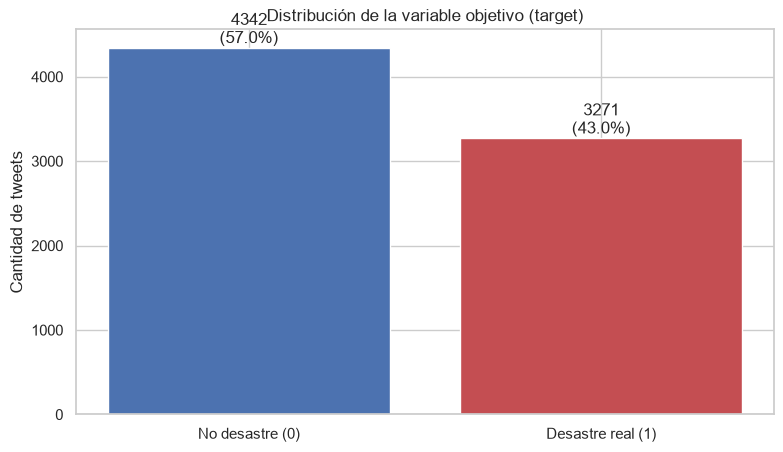

target
0    4342
1    3271
Name: count, dtype: int64


In [5]:
target_counts = df["target"].value_counts().sort_index()
target_pct = (target_counts / len(df) * 100).round(1)

fig, ax = plt.subplots()
bars = ax.bar(["No desastre (0)", "Desastre real (1)"], target_counts.values,
              color=["#4C72B0", "#C44E52"])
for bar, pct in zip(bars, target_pct.values):
    ax.annotate(f"{bar.get_height()}\n({pct}%)", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom")
ax.set_ylabel("Cantidad de tweets")
ax.set_title("Distribución de la variable objetivo (target)")
plt.show()

print(target_counts)


**Balance de clases:** el dataset está moderadamente desbalanceado (~57% no-desastre vs. ~43% desastre real), pero no de forma extrema. Se tomará en cuenta al evaluar los modelos (usar métricas como *precision*, *recall* y *F1*, no solo *accuracy*, y aplicar `stratify` en el split de entrenamiento/prueba).


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18624\1112829799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keyword_counts.values, y=keyword_counts.index, ax=ax, palette="viridis")


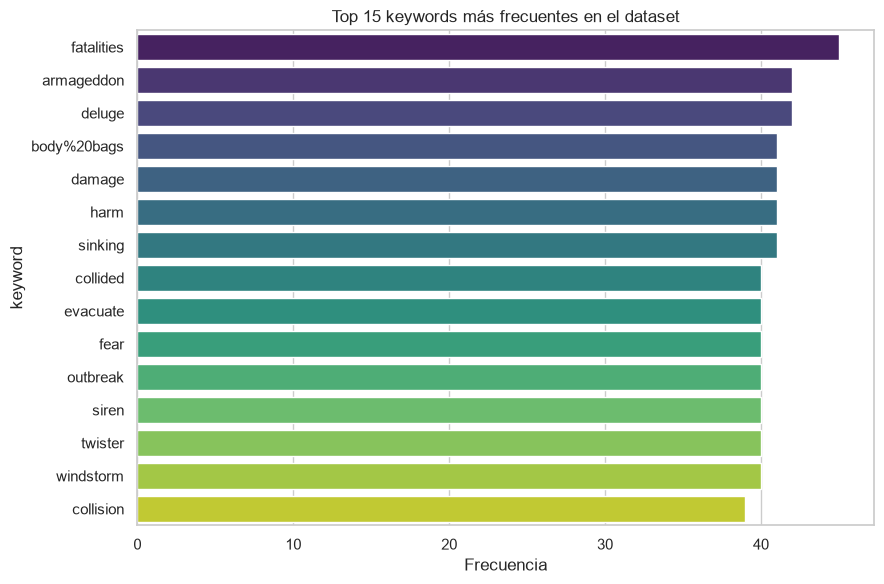

In [6]:
keyword_counts = df["keyword"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=keyword_counts.values, y=keyword_counts.index, ax=ax, palette="viridis")
ax.set_xlabel("Frecuencia")
ax.set_title("Top 15 keywords más frecuentes en el dataset")
plt.tight_layout()
plt.show()


In [7]:
disaster_rate_by_keyword = (
    df.dropna(subset=["keyword"])
      .groupby("keyword")["target"]
      .agg(["mean", "count"])
      .rename(columns={"mean": "tasa_desastre", "count": "n_tweets"})
)

print("Keywords MÁS asociadas a desastre real:")
print(disaster_rate_by_keyword[disaster_rate_by_keyword["n_tweets"] >= 10].sort_values("tasa_desastre", ascending=False).head(10))

print("\nKeywords MENOS asociadas a desastre real:")
print(disaster_rate_by_keyword[disaster_rate_by_keyword["n_tweets"] >= 10].sort_values("tasa_desastre", ascending=True).head(10))


Keywords MÁS asociadas a desastre real:
                   tasa_desastre  n_tweets
keyword                                   
debris                  1.000000        37
derailment              1.000000        39
wreckage                1.000000        39
outbreak                0.975000        40
oil%20spill             0.973684        38
typhoon                 0.973684        38
suicide%20bombing       0.969697        33
suicide%20bomber        0.967742        31
bombing                 0.931034        29
suicide%20bomb          0.914286        35

Keywords MENOS asociadas a desastre real:
             tasa_desastre  n_tweets
keyword                             
aftershock        0.000000        34
body%20bags       0.024390        41
ruin              0.027027        37
blazing           0.029412        34
body%20bag        0.030303        33
electrocute       0.031250        32
screaming         0.055556        36
traumatised       0.057143        35
panicking         0.060606     

**Observación:** existen keywords casi perfectamente asociadas a una clase (p. ej. `debris`, `wreckage`, `derailment` casi siempre son desastre real; `aftershock` casi nunca lo es a pesar del nombre). Esto sugiere que `keyword`, aunque no es el foco del análisis de texto libre, **podría usarse como variable auxiliar** en el modelo final.


## 3. Limpieza y preprocesamiento del texto

Los tweets son texto ruidoso: contienen URLs, menciones (`@usuario`), hashtags, entidades HTML (`&amp;`), emojis, errores de codificación (mojibake) y puntuación. Se documenta cada paso por separado para poder justificar las decisiones tomadas, tal como pide el enunciado.

Se muestran ejemplos reales del propio dataset para justificar cada regla.


In [8]:
ejemplos = [
    df[df["text"].str.contains("http", na=False)]["text"].iloc[0],
    df[df["text"].str.contains("&amp;", na=False)]["text"].iloc[0],
    df[df["text"].str.contains("911", na=False)]["text"].iloc[1],
]
for e in ejemplos:
    print("-", e)


- @bbcmtd Wholesale Markets ablaze http://t.co/lHYXEOHY6C
- Rene Ablaze &amp; Jacinta - Secret 2k13 (Fallen Skies Edit) - Mar 30 2013  https://t.co/7MLMsUzV1Z
- Came across this fire video not mine..enjoy..#fire #firemen #firetruck #emergency #rescue #911 #summertime #sirensÛ_ http://t.co/hcYAJsAcfJ


### 3.1. Pasos de limpieza aplicados y justificación

1. **Minúsculas**: se normaliza todo el texto a minúsculas para que `Fire`, `FIRE` y `fire` se traten como el mismo token.
2. **Entidades HTML** (`&amp;`, `&lt;`, `&gt;`, `&quot;`): Twitter codifica caracteres especiales como entidades HTML; se decodifican a su símbolo real (p. ej. `&amp;` → `&`) antes de continuar.
3. **URLs**: se eliminan por completo (`http://...`, `https://...`, `www...`). No aportan información semántica sobre el contenido del tweet y son casi únicas por tweet, por lo que solo añadirían ruido/dimensionalidad al vocabulario.
4. **Menciones (`@usuario`)**: se eliminan. El nombre de usuario mencionado no aporta señal sobre si el tweet describe un desastre real.
5. **Símbolo de hashtag (`#`)**: se elimina el símbolo pero **se conserva la palabra** (`#earthquake` → `earthquake`), ya que el término dentro del hashtag sí es relevante para la clasificación.
6. **Emojis y emoticones**: se eliminan en esta etapa de limpieza para el modelo de bag-of-words / TF-IDF. *Nota:* en la sección de análisis de sentimiento (entrega final) se evaluará si conservarlos aporta señal adicional, ya que un emoji como 😢 o 🔥 podría ser informativo del tono del tweet.
7. **Caracteres de codificación corrupta (mojibake)** como `\x89Û_`: se eliminan junto con cualquier carácter no imprimible/no-ASCII, ya que corresponden a errores de encoding de comillas/apóstrofes y no a información útil.
8. **Puntuación y caracteres especiales**: se eliminan los signos de puntuación (`.`, `,`, `!`, `?`, `'`, `"`, etc.).
9. **Espacios múltiples**: se colapsan a un solo espacio y se recortan los extremos.
10. **Números**: se decidió **conservarlos** en lugar de eliminarlos. La razón es el propio caso mencionado en el enunciado: `911` es un token con fuerte señal de emergencia real; eliminar todos los números perdería esa información. Se filtrarán después, en la etapa de modelado, solo si el análisis de frecuencias muestra que no aportan valor discriminativo.
11. **Tokenización**: se separa el texto limpio en palabras individuales usando `nltk.word_tokenize`.
12. **Stopwords**: se eliminan artículos, preposiciones y conjunciones en inglés (dataset en inglés) usando la lista de `nltk.corpus.stopwords`, ya que son palabras de altísima frecuencia en ambas clases y no ayudan a discriminar entre desastre real o no.


In [9]:
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

stop_words = set(stopwords.words("english"))
print(f"Cantidad de stopwords en inglés: {len(stop_words)}")
print(sorted(list(stop_words))[:15])


Cantidad de stopwords en inglés: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


In [10]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_SYMBOL_RE = re.compile(r"#")
HTML_ENTITIES = {
    "&amp;": "&", "&lt;": "<", "&gt;": ">", "&quot;": '"', "&#39;": "'",
}
EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001FAFF"  # símbolos, pictogramas, emoticones, transporte
    "\U00002600-\U000027BF"  # símbolos diversos y dingbats
    "\U0001F1E0-\U0001F1FF"  # banderas
    "]+", flags=re.UNICODE
)
NON_ASCII_RE = re.compile(r"[^\x00-\x7F]+")
PUNCT_TABLE = str.maketrans("", "", string.punctuation)
MULTI_SPACE_RE = re.compile(r"\s+")


def decode_html_entities(text):
    for entity, char in HTML_ENTITIES.items():
        text = text.replace(entity, char)
    return text


def clean_text(text, keep_numbers=True):
    text = text.lower()
    text = decode_html_entities(text)
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = HASHTAG_SYMBOL_RE.sub("", text)      # quita '#' pero deja la palabra
    text = EMOJI_RE.sub(" ", text)
    text = NON_ASCII_RE.sub(" ", text)          # limpia mojibake / restos de encoding
    text = text.translate(PUNCT_TABLE)          # quita puntuación
    if not keep_numbers:
        text = re.sub(r"\d+", " ", text)
    text = MULTI_SPACE_RE.sub(" ", text).strip()
    return text


def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in stop_words and len(t) > 1]


In [11]:
# Demostración del pipeline paso a paso sobre ejemplos reales del dataset
demo = df["text"].iloc[[0, 3, 9]].tolist() + [
    df[df["text"].str.contains("&amp;", na=False)]["text"].iloc[0]
]

for original in demo:
    limpio = clean_text(original)
    tokens = tokenize_and_remove_stopwords(limpio)
    print("ORIGINAL :", original)
    print("LIMPIO   :", limpio)
    print("TOKENS   :", tokens)
    print("-" * 100)


ORIGINAL : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
LIMPIO   : our deeds are the reason of this earthquake may allah forgive us all
TOKENS   : ['deeds', 'reason', 'earthquake', 'may', 'allah', 'forgive', 'us']
----------------------------------------------------------------------------------------------------
ORIGINAL : 13,000 people receive #wildfires evacuation orders in California 
LIMPIO   : 13000 people receive wildfires evacuation orders in california
TOKENS   : ['13000', 'people', 'receive', 'wildfires', 'evacuation', 'orders', 'california']
----------------------------------------------------------------------------------------------------
ORIGINAL : I'm afraid that the tornado is coming to our area...
LIMPIO   : im afraid that the tornado is coming to our area
TOKENS   : ['im', 'afraid', 'tornado', 'coming', 'area']
----------------------------------------------------------------------------------------------------
ORIGINAL : Rene Ablaze &amp; Jaci

In [12]:
df["clean_text"] = df["text"].apply(clean_text)
df["tokens"] = df["clean_text"].apply(tokenize_and_remove_stopwords)
df["clean_text_no_stop"] = df["tokens"].apply(lambda toks: " ".join(toks))

df[["text", "clean_text", "clean_text_no_stop"]].head(10)


,text,clean_text,clean_text_no_stop
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...,deeds reason earthquake may allah forgive us
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",13000 people receive wildfires evacuation orde...,13000 people receive wildfires evacuation orde...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...,got sent photo ruby alaska smoke wildfires pou...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy 20 closed in b...,rockyfire update california hwy 20 closed dire...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,im on top of the hill and i can see a fire in ...,im top hill see fire woods
8,There's an emergency evacuation happening now ...,theres an emergency evacuation happening now i...,theres emergency evacuation happening building...
9,I'm afraid that the tornado is coming to our a...,im afraid that the tornado is coming to our area,im afraid tornado coming area


Con esto, cada tweet ahora cuenta con:

- `clean_text`: texto limpio (minúsculas, sin URLs/menciones/emojis/puntuación) pero **con stopwords**, útil para vectorizadores que ya filtran stopwords internamente (p. ej. `TfidfVectorizer(stop_words="english")`).
- `tokens` / `clean_text_no_stop`: versión tokenizada **sin stopwords**, usada para los análisis de frecuencia, n-gramas y nube de palabras.


## 4. Frecuencia de palabras (unigramas)

Se calcula la frecuencia de palabras por separado para tweets de desastre real (`target = 1`) y de no-desastre (`target = 0`), para identificar qué términos son característicos de cada clase.


In [13]:
def word_freq(tokens_series, top_n=20):
    counter = Counter()
    for tokens in tokens_series:
        counter.update(tokens)
    return counter.most_common(top_n)


freq_disaster = word_freq(df.loc[df["target"] == 1, "tokens"])
freq_no_disaster = word_freq(df.loc[df["target"] == 0, "tokens"])

print("Top 20 palabras — DESASTRE REAL (target=1):")
for w, c in freq_disaster:
    print(f"  {w:<15} {c}")

print("\nTop 20 palabras — NO DESASTRE (target=0):")
for w, c in freq_no_disaster:
    print(f"  {w:<15} {c}")


Top 20 palabras — DESASTRE REAL (target=1):
  fire            180
  news            135
  via             121
  disaster        118
  california      111
  suicide         110
  police          107
  people          105
  killed          93
  like            92
  hiroshima       87
  crash           85
  fires           85
  storm           85
  us              81
  families        81
  train           79
  emergency       76
  buildings       76
  bomb            75

Top 20 palabras — NO DESASTRE (target=0):
  like            253
  im              244
  new             171
  get             163
  dont            141
  one             129
  body            113
  via             99
  would           97
  video           96
  got             92
  people          91
  love            90
  know            85
  back            84
  us              83
  time            82
  see             82
  full            82
  cant            81


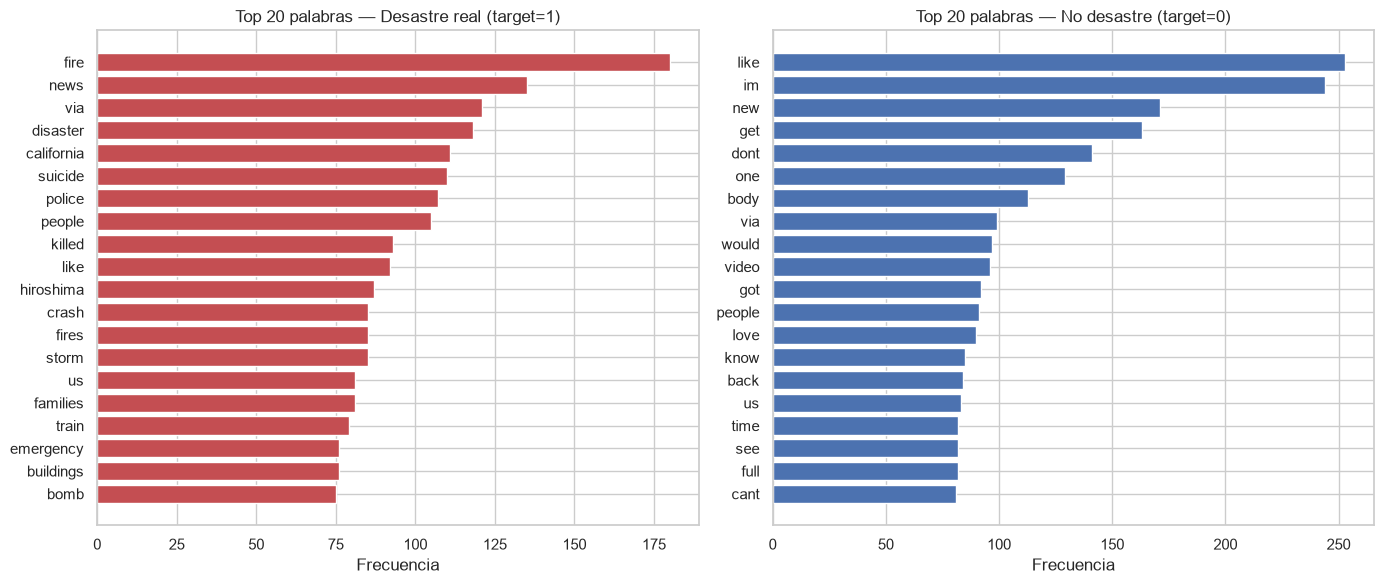

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

words1, counts1 = zip(*freq_disaster)
axes[0].barh(words1[::-1], counts1[::-1], color="#C44E52")
axes[0].set_title("Top 20 palabras — Desastre real (target=1)")
axes[0].set_xlabel("Frecuencia")

words0, counts0 = zip(*freq_no_disaster)
axes[1].barh(words0[::-1], counts0[::-1], color="#4C72B0")
axes[1].set_title("Top 20 palabras — No desastre (target=0)")
axes[1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()


In [15]:
set_disaster = set(w for w, _ in freq_disaster)
set_no_disaster = set(w for w, _ in freq_no_disaster)
comunes = set_disaster & set_no_disaster
print(f"Palabras en el top 20 de AMBAS categorías ({len(comunes)}): {comunes}")


Palabras en el top 20 de AMBAS categorías (4): {'us', 'via', 'like', 'people'}


**Discusión:**

- Palabras como `like`, `new`, `via`, `get` aparecen frecuentes en ambas categorías: son términos genéricos de Twitter sin carga semántica sobre desastres, por lo que **aportan poco poder discriminativo** por sí solas y son candidatas a tratarse casi como stopwords adicionales del dominio.
- Palabras específicas de la clase 1 como `fire`, `california`, `suicide`, `killed`, `flood`, `storm`, `bomb`, `disaster` sí parecen tener alto valor discriminativo: describen eventos concretos de desastre o violencia.
- La clase 0 muestra palabras de uso coloquial/figurado (`love`, `body`, `full`, `people`, `time`) que corresponden a usos metafóricos de palabras clave (p. ej. "ablaze" usado como "me encanta" y no como incendio real), lo cual confirma la importancia del **contexto** y no solo de palabras sueltas.
- **Sí vale la pena explorar bigramas/trigramas**: muchas palabras clave del dataset (`suicide bomb`, `forest fire`, `oil spill`) solo cobran su significado real de desastre cuando se analizan en combinación con la palabra siguiente/anterior; un unigrama aislado como "bomb" no distingue "bomb threat" (desastre) de "the bomb" (jerga positiva).
